In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

In [2]:
df_pollutant = pd.read_csv(r"D:\Coding\data\Lanzhou_pollution\Xiaolei_Wang\1479A_data.csv")
df_inp = pd.read_csv(r"D:\Coding\data\Lanzhou_cfdc\processed\N_INP(202409-202509)v2.4.1.csv")
print(df_inp.shape)
df_inp['Date'] = pd.to_datetime(df_inp['Date'])
df_inp = df_inp[df_inp['Is_Significant'] == True]
print(df_inp.shape)
df_pollutant['Date'] = pd.to_datetime(df_pollutant['Date'])
df_pollutant = df_pollutant[(df_pollutant['Date']>='2024-09-17') & (df_pollutant['Date']<='2025-10-1')]


(2707, 10)
(2012, 10)


In [3]:
df_merged = pd.merge_asof(df_inp, df_pollutant, on="Date", direction='nearest', tolerance=pd.Timedelta('1h'))
print(df_merged.head())

                        Date  N_inp_net(#/L)  T_inp(°C)      SS_w       SS_i  \
0 2024-09-24 14:41:43.068586       14.050137 -29.797332  5.761454  41.444960   
1 2024-09-26 14:13:58.060174       31.918336 -29.789597  5.983611  41.736518   
2 2024-09-26 14:26:14.060563       27.829487 -29.781749  5.968580  41.693702   
3 2024-09-26 16:07:50.060424       15.449528 -29.756955  4.246887  39.362124   
4 2024-09-26 16:20:06.060029        6.189200 -29.747240  4.200907  39.280730   

   Total_Sampling_Volume(L)  Significance_Level(#/L)  Is_Significant  season  \
0                  6.149300                 2.617877            True  Autumn   
1                  6.291500                 4.248877            True  Autumn   
2                  6.266200                 4.178253            True  Autumn   
3                  6.032083                 4.010179            True  Autumn   
4                  6.042150                 3.872997            True  Autumn   

   T_a(°C)  ...   SO2  SO2_24h   NO2  

## 计算某个污染物与某个温度下的INP浓度的相关性

In [11]:
# 数据清洗

POLLUTANT_COLUMN = 'CO_24h'  # 替换为你感兴趣的污染物列名
TEMPERATURE = -35  # 替换为你感兴趣的激活温度
LOG_TAG = 0  # 若为1, 则对数据取对数后, 再计算 Pearson 相关系数; 若为0, 则使用原始数据计算 Pearson 相关系数

df_clean = df_merged.dropna(subset=[POLLUTANT_COLUMN, 'N_inp_net(#/L)'])
print(f'原始数据点数量: {len(df_merged)}')
print(f"清洗后数据点数量: {len(df_clean)}")
df_selected = df_clean[df_clean['T_a(°C)'] == TEMPERATURE]
print(f"选择激活温度 {TEMPERATURE}°C 后数据点数量: {len(df_selected)}")

原始数据点数量: 3062
清洗后数据点数量: 3036
选择激活温度 -35°C 后数据点数量: 430


Spearman 相关系数: -0.2513
------------------------------
Pearson 相关系数 (r): -0.2287
P值 (p-value):       1.6429e-06
------------------------------
结论: 在 0.05 水平上显著相关。


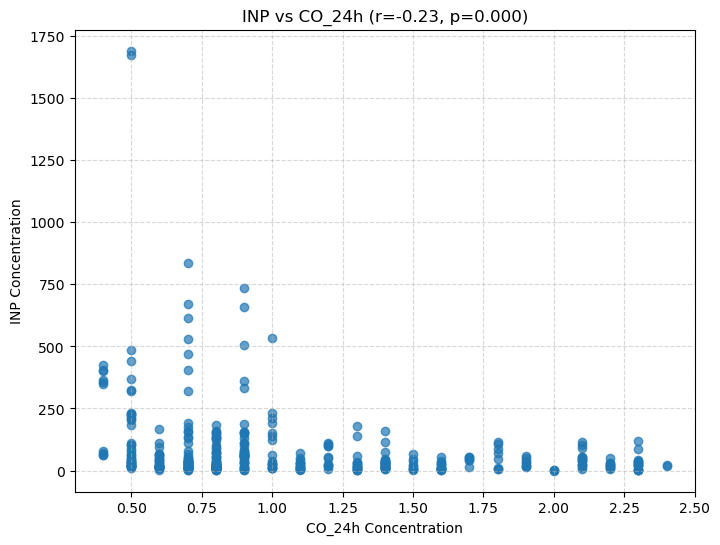

In [12]:
# 相关性分析

# 提取数组
x = df_selected[POLLUTANT_COLUMN]
y = df_selected['N_inp_net(#/L)']
log_x = np.log10(x)
log_y = np.log10(y)

# 计算 Pearson 相关系数和 p值
# 注意：Pearson假设数据符合正态分布
r_value, p_value = stats.pearsonr(x, y)
if LOG_TAG:
    r_value, p_value = stats.pearsonr(log_x, log_y)
r_spearman, p_spearman = stats.spearmanr(x, y)
print(f"Spearman 相关系数: {r_spearman:.4f}")

print("-" * 30)
print(f"Pearson 相关系数 (r): {r_value:.4f}")
print(f"P值 (p-value):       {p_value:.4e}")
print("-" * 30)

# 判断显著性
if p_value < 0.05:
    print("结论: 在 0.05 水平上显著相关。")
else:
   print("结论: 相关性不显著。")

# (可选) 简单的绘图检查
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7)
plt.title(f"INP vs {POLLUTANT_COLUMN} (r={r_value:.2f}, p={p_value:.3f})")
plt.xlabel(f"{POLLUTANT_COLUMN} Concentration")
plt.ylabel("INP Concentration")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [13]:
# ==========================================
# 1. 配置参数
# ==========================================
# 假设 df_merged 是你已经对齐好时间的数据
# 确保 'T_a(°C)' 是数字类型

# 你感兴趣的所有污染物列表
POLLUTANT_LIST = [
    'AQI', 'PM2.5', 'PM2.5_24h', 'PM10', 'PM10_24h',
    'SO2', 'SO2_24h', 'NO2', 'NO2_24h', 
    'O3', 'O3_24h', 'O3_8h', 'O3_8h_24h', 
    'CO', 'CO_24h'
]

# 你感兴趣的激活温度列表 (根据你的数据调整)
TEMPERATURE_LIST = [-35, -30, -25, -20, -15]

# INP 浓度列名
INP_COL = 'N_inp_net(#/L)'

# 是否取对数 (1:是, 0:否)
LOG_TAG = 0

# ==========================================
# 2. 定义计算函数
# ==========================================
def calculate_corr_cell(df, temp, pollutant, log_tag):
    """
    计算特定温度下，INP与特定污染物的相关系数
    返回格式化的字符串 (例如: "0.38*" 或 "0.12")
    """
    # 1. 筛选特定温度的数据
    df_temp = df[df['T_a(°C)'] == temp]
    
    # 2. 去除空值 (Pairwise deletion)
    df_sub = df_temp.dropna(subset=[pollutant, INP_COL])
    
    # 3. 样本量检查 (如果样本太少，无法计算)
    if len(df_sub) < 3:
        return "nan" # 或者返回 "/"
    
    # 4. 提取数据
    x = df_sub[pollutant]
    y = df_sub[INP_COL]
    
    # 5. 对数转换逻辑
    if log_tag:
        # 对数转换前必须确保数据 > 0
        valid_idx = (x > 0) & (y > 0)
        x = np.log10(x[valid_idx])
        y = np.log10(y[valid_idx])
        if len(x) < 3: return "nan"

    # 6. 计算 Pearson r 和 p
    # 如果数据方差为0（所有值都一样），pearsonr会报警告或返回nan，这里用try-except捕获
    try:
        r, p = stats.pearsonr(x, y)
    except Exception:
        return "nan"

    # 7. 格式化输出
    if pd.isna(r):
        return "nan"
    
    # 标记显著性 (* 代表 p < 0.05)
    star = "*" if p < 0.05 else ""

    star = "**" if p < 0.01 else star
    
    # 这里保留2位小数，你可以根据需要改成 .3f
    return f"{r:.2f}{star}"

# ==========================================
# 3. 批量计算
# ==========================================
results = {}

print("开始批量计算相关系数...")

for temp in TEMPERATURE_LIST:
    row_name = f"INP{temp}" # 生成行名，如 INP-35
    row_data = {}
    
    for pollutant in POLLUTANT_LIST:
        # 检查污染物列是否存在于数据中
        if pollutant not in df_merged.columns:
            row_data[pollutant] = "No Data"
            continue
            
        # 调用函数计算
        res_str = calculate_corr_cell(df_merged, temp, pollutant, LOG_TAG)
        row_data[pollutant] = res_str
    
    results[row_name] = row_data

# ==========================================
# 4. 生成表格并保存
# ==========================================
# 转换为 DataFrame (行是温度，列是污染物)
df_result = pd.DataFrame(results).T 

# 打印预览
print("-" * 50)
print("Pearson 相关系数表 (带显著性标记 *)")
print("-" * 50)
print(df_result)

# 保存到 Excel
output_filename = 'Pearson_Correlation_Table.xlsx'
df_result.to_excel(output_filename)
print(f"\n结果已保存至: {output_filename}")


开始批量计算相关系数...
--------------------------------------------------
Pearson 相关系数表 (带显著性标记 *)
--------------------------------------------------
           AQI   PM2.5 PM2.5_24h    PM10 PM10_24h      SO2  SO2_24h     NO2  \
INP-35  0.41**  0.24**    0.23**  0.35**   0.30**   -0.12*  -0.15**  -0.12*   
INP-30  0.37**  0.24**    0.19**  0.35**   0.27**  -0.13**   -0.07*   -0.05   
INP-25  0.24**  0.21**    0.27**  0.20**   0.27**    -0.03    -0.03    0.04   
INP-20   -0.02    0.04     0.21*    0.04     0.16    -0.04    -0.02    0.01   
INP-15  0.61**  0.52**     -0.04   0.40*     0.10     0.04    -0.20    0.00   

        NO2_24h       O3 O3_24h   O3_8h O3_8h_24h       CO   CO_24h  
INP-35  -0.23**     0.07    nan  0.17**    0.16**  -0.18**  -0.24**  
INP-30  -0.11**  -0.08**    nan  0.20**    0.19**  -0.11**  -0.19**  
INP-25    -0.04    -0.04    nan   0.14*     0.15*    -0.00    -0.08  
INP-20     0.01    -0.18    nan   -0.15     -0.17     0.15    -0.05  
INP-15    -0.29    -0.13    nan   

In [ ]:
# ==========================================
# 1. 配置参数
# ==========================================

# >>> 修改这里来切换方法 <<<
# 选项: 'pearson' 或 'spearman'
METHOD = 'spearman' 

POLLUTANT_LIST = [
    'AQI', 'PM2.5', 'PM2.5_24h', 'PM10', 'PM10_24h',
    'SO2', 'SO2_24h', 'NO2', 'NO2_24h', 
    'O3', 'O3_24h', 'O3_8h', 'O3_8h_24h', 
    'CO', 'CO_24h'
]

TEMPERATURE_LIST = [-35, -30, -25, -20, -15] # 根据实际情况调整
INP_COL = 'N_inp_net(#/L)'

# 注意：对于 Spearman，取对数通常不会改变结果，建议设为 0
LOG_TAG = 0 

# ==========================================
# 2. 定义计算函数
# ==========================================
def calculate_corr_cell(df, temp, pollutant, log_tag, method):
    # 1. 筛选特定温度
    df_temp = df[df['T_a(°C)'] == temp]
    
    # 2. 去除空值 (Pairwise deletion)
    df_sub = df_temp.dropna(subset=[pollutant, INP_COL])
    
    # 3. 样本量检查
    if len(df_sub) < 3:
        return "nan"
    
    # 4. 提取数据
    x = df_sub[pollutant]
    y = df_sub[INP_COL]
    
    # 5. 对数转换 (仅当 LOG_TAG=1 且数据>0 时)
    if log_tag:
        valid_idx = (x > 0) & (y > 0)
        x = np.log10(x[valid_idx])
        y = np.log10(y[valid_idx])
        if len(x) < 3: return "nan"

    # 6. 计算相关系数 (核心部分)
    try:
        if method == 'pearson':
            r, p = stats.pearsonr(x, y)
        elif method == 'spearman':
            # Spearmanr 计算秩相关
            r, p = stats.spearmanr(x, y)
        else:
            return "Error"
    except Exception:
        return "nan"

    # 7. 格式化输出
    if pd.isna(r):
        return "nan"
    
    # 标记显著性 (* 代表 p < 0.05)
    star = "*" if p < 0.05 else ""

    star = "**" if p < 0.01 else star
    
    return f"{r:.2f}{star}"

# ==========================================
# 3. 批量计算
# ==========================================
results = {}

print(f"开始批量计算 {METHOD.capitalize()} 相关系数...")

for temp in TEMPERATURE_LIST:
    row_name = f"INP{temp}"
    row_data = {}
    
    for pollutant in POLLUTANT_LIST:
        if pollutant not in df_merged.columns:
            row_data[pollutant] = "-"
            continue
            
        # 传入 method 参数
        res_str = calculate_corr_cell(df_merged, temp, pollutant, LOG_TAG, METHOD)
        row_data[pollutant] = res_str
    
    results[row_name] = row_data

# ==========================================
# 4. 生成表格并保存
# ==========================================
df_result = pd.DataFrame(results).T 

print("-" * 50)
print(f"{METHOD.capitalize()} 相关系数表 (带显著性标记 *)")
print("-" * 50)
print(df_result)

output_filename = f'{METHOD.capitalize()}_Correlation_Table.xlsx'
df_result.to_excel(output_filename)
print(f"\n结果已保存至: {output_filename}")


开始批量计算 Spearman 相关系数...
--------------------------------------------------
Spearman 相关系数表 (带显著性标记 *)
--------------------------------------------------
           AQI   PM2.5 PM2.5_24h    PM10 PM10_24h      SO2  SO2_24h      NO2  \
INP-35  0.28**    0.03      0.09  0.31**   0.31**   -0.12*  -0.15**  -0.16**   
INP-30  0.22**  0.11**    0.09**  0.28**   0.22**  -0.15**  -0.16**  -0.16**   
INP-25  0.40**  0.20**    0.23**  0.40**   0.34**    -0.12    -0.02    -0.09   
INP-20    0.02   -0.02      0.07    0.04     0.16    -0.10     0.05    -0.10   
INP-15    0.22   -0.01     -0.05    0.20     0.17    -0.07    -0.19    -0.12   

        NO2_24h      O3 O3_24h   O3_8h O3_8h_24h       CO   CO_24h  
INP-35  -0.26**  0.17**    nan  0.30**    0.27**  -0.19**  -0.27**  
INP-30  -0.21**  0.13**    nan  0.34**    0.33**  -0.22**  -0.26**  
INP-25    -0.04    0.07    nan  0.26**    0.28**  -0.19**   -0.13*  
INP-20     0.01    0.07    nan    0.06      0.07    -0.07     0.02  
INP-15    -0.21   -0.0